In [40]:
import torch
import torchvision
from torchvision import transforms

from d2l import torch as d2l
import matplotlib.pyplot as plt

In [41]:
root = '../data/'

In [42]:
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor()
])

train = torchvision.datasets.FashionMNIST(
    root=root,
    train=True,
    download=True,
    transform=transform
)

val = torchvision.datasets.FashionMNIST(
    root=root,
    train=False,
    download=True,
    transform=transform
)

In [43]:
len(train), len(val)

(60000, 10000)

In [44]:
class FashionMNIST:
    def __init__(self, root='../data/', batch_size=64, resize=(28, 28), num_workers=2):
        self.root = root
        self.batch_size = batch_size
        self.num_workers = num_workers

        transform = transforms.Compose([
            transforms.Resize(resize),
            transforms.ToTensor()
        ])

        self.train = torchvision.datasets.FashionMNIST(
            root=self.root,
            train=True,
            download=True,
            transform=transform
        )

        self.val = torchvision.datasets.FashionMNIST(
            root=self.root,
            train=False,
            download=True,
            transform=transform
        )

    def text_labels(self, indices):
        labels = [
            't-shirt', 'trouser', 'pullover', 'dress', 'coat',
            'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot'
        ]

        return [labels[int(i)] for i in indices]

    def get_dataloader(self, train):
        data = self.train if train else self.val

        return torch.utils.data.DataLoader(
            data,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers
        )

    
    
    def visualize(self, batch, nrows=1, ncols=8, labels=[]):
        X, y = batch
        if not labels:
            labels = self.text_labels(y)
        d2l.show_images(X.squeeze(1), nrows, ncols, titles=labels)

In [45]:
data = FashionMNIST(resize=(32, 32))

train_loader = data.get_dataloader(train=True)

In [50]:
batch = next(iter(train_loader))

X, y = batch

X.shape, y.shape

(torch.Size([64, 1, 32, 32]), torch.Size([64]))

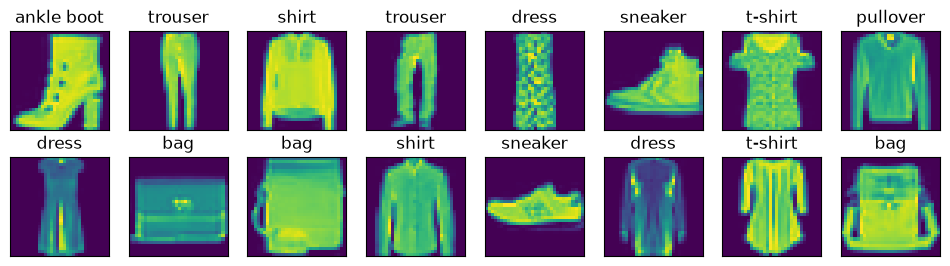

In [51]:
data.visualize(batch, nrows=2)